In [1]:
from src.runner import preprocess
# preprocess(orgs_to_skip=['CALCE', 'HNEI', 'OX', 'ORNL', 'SNL', 'ULPurdue', 
#                 'SynthGasTR', 'Lithos', 'TROvercharge', 'TROverheat', 'HealthyCRPS', 
#                 'LithosNorm', 'LithosTR', 'Lithos2Norm', 'Lithos2TR', 'ULNorm', 'ULTR'], silentErrs=False)
preprocess()

Processing Center for Advanced Life Cycle Engineering cells: 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]


0 processed, 7 skipped



Processing Hawaii Natural Energy Institute cells: 100%|██████████| 15/15 [00:04<00:00,  3.27it/s]


0 processed, 15 skipped



Processing Oxford cells: 100%|██████████| 8/8 [00:01<00:00,  4.55it/s]


...

11 processed, 0 skipped



Processing Cell Report Physical Science cells: 100%|██████████| 33/33 [00:00<00:00, 1049.48it/s]


33 processed, 0 skipped



Processing Cell Report Physical Science cells: 100%|██████████| 33/33 [00:00<00:00, 322.81it/s]

33 processed, 0 skipped



In [30]:
from src.preprocessing.preprocess_crps_Final import *

preprocessor = CRPSPreprocessor(silent=False)
preprocessor.get_timeseries_data(
    inputdir='data/raw/Final Datasets/TR/CRPS_Final_TR',
    cell='Figure3b'
)

In [28]:
import pandas as pd
pd.read_csv('data/raw/Final Datasets/TR/CRPS_Final_TR/Figure3a.csv')[['time',	'H2', 'temp']].dropna(axis=0).to_csv(
    'data/raw/Final Datasets/TR/CRPS_Final_TR/Figure3a.csv'
)

In [3]:
import os
from src.data import BatteryData


import glob
import random

total_files = 0
org_counts = {}
temp_only = {}
temp_gas = {}

for filename in glob.glob("data/preprocessed/*"):
    total_files += 1
    # name = filename.split('/')[-1].split('.')[0]
    # name = f"data/preprocessed/{name}.pkl"
    # healthy_test_files.append(name) if random.uniform(0, 1) < 0.2 else healthy_train_files.append(name)
    bd = BatteryData.load(filename)

    if bd.has_gas:
        org_dict = temp_gas.get(bd.organization, None)
        if org_dict is None:
            temp_gas[bd.organization] = {'norm': 0, 'tr': 0}

        if bd.is_healthy:
            temp_gas[bd.organization]['norm'] += 1
        else: temp_gas[bd.organization]['tr'] += 1
    else:
        org_dict = temp_only.get(bd.organization, None)
        if org_dict is None:
            temp_only[bd.organization] = {'norm': 0, 'tr': 0}

        if bd.is_healthy:
            temp_only[bd.organization]['norm'] += 1
        else: temp_only[bd.organization]['tr'] += 1



    # org_counts[bd.organization] = org_counts.get(bd.organization, 0) + 1
print(f"TOTAL FILE COUNT = {total_files}")
# org_counts
temp_only


TOTAL FILE COUNT = 541


{'ul-purdue': {'norm': 21, 'tr': 0},
 'snl': {'norm': 74, 'tr': 54},
 'oakridge': {'norm': 0, 'tr': 175},
 'oxford': {'norm': 8, 'tr': 0}}

In [6]:
healthy_train_cells = ["data/preprocessed/UL-PUR_R20-EX2_18650_NCA_23C_2.5-96.5_0.5-0.5C_b_timeseries.pkl", "data/preprocessed/UL-PUR_R15-EX4_18650_NCA_23C_2.5-96.5_0.5-0.5C_d_timeseries.pkl", "data/preprocessed/OX_1-7_pouch_LCO_40C_0-100_2-1.84C_g_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_35C_0-100_0.5-1C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-1C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_15C_0-100_0.5-2C_b_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_40-60_0.5-3C_a_timeseries.pkl", "data/preprocessed/OX_1-5_pouch_LCO_40C_0-100_2-1.84C_e_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-3C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_35C_0-100_0.5-2C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-1C_c_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_20-80_0.5-3C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-1C_d_timeseries.pkl", "data/preprocessed/UL-PUR_N20-OV1_18650_NCA_23C_0-100_0.5-0.5C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-2C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_15C_0-100_0.5-1C_a_timeseries.pkl", "data/preprocessed/UL-PUR_R20-NA7_18650_NCA_23C_2.5-96.5_0.5-0.5C_g_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_35C_0-100_0.5-1C_a_timeseries.pkl", "data/preprocessed/OX_1-2_pouch_LCO_40C_0-100_2-1.84C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_20-80_0.5-0.5C_b_timeseries.pkl", "data/preprocessed/UL-PUR_R10-NA11_18650_NCA_23C_2.5-96.5_0.5-0.5C_k_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-3C_b_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_40-60_0.5-3C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_20-80_0.5-0.5C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-1C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_15C_0-100_0.5-2C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_20-80_0.5-0.5C_c_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_20-80_0.5-0.5C_d_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_0-100_0.5-0.5C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-3C_c_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_35C_0-100_0.5-2C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-2C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_20-80_0.5-0.5C_d_timeseries.pkl", "data/preprocessed/UL-PUR_R15-NA10_18650_NCA_23C_2.5-96.5_0.5-0.5C_j_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_15C_0-100_0.5-1C_b_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_40-60_0.5-0.5C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_20-80_0.5-0.5C_c_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-3C_d_timeseries.pkl", "data/preprocessed/UL-PUR_N15-EX4_18650_NCA_23C_0-100_0.5-0.5C_d_timeseries.pkl", "data/preprocessed/OX_1-8_pouch_LCO_40C_0-100_2-1.84C_h_timeseries.pkl", "data/preprocessed/OX_1-1_pouch_LCO_40C_0-100_2-1.84C_a_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_20-80_0.5-0.5C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_20-80_0.5-3C_b_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_15C_0-100_0.5-1C_b_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_0-100_0.5-3C_c_timeseries.pkl", "data/preprocessed/OX_1-3_pouch_LCO_40C_0-100_2-1.84C_c_timeseries.pkl", "data/preprocessed/UL-PUR_R10-EX6_18650_NCA_23C_2.5-96.5_0.5-0.5C_f_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_15C_0-100_0.5-2C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_0-100_0.5-1C_a_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_20-80_0.5-0.5C_d_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_0-100_0.5-1C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_40-60_0.5-0.5C_a_timeseries.pkl", "data/preprocessed/UL-PUR_R20-OV1_18650_NCA_23C_2.5-96.5_0.5-0.5C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_40-60_0.5-3C_b_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_0-100_0.5-3C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_35C_0-100_0.5-2C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_15C_0-100_0.5-1C_b_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_20-80_0.5-0.5C_c_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_40-60_0.5-0.5C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-0.5C_a_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_0-100_0.5-2C_a_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_20-80_0.5-0.5C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_20-80_0.5-3C_a_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_0-100_0.5-1C_d_timeseries.pkl", "data/preprocessed/UL-PUR_R20-NA9_18650_NCA_23C_2.5-96.5_0.5-0.5C_i_timeseries.pkl", "data/preprocessed/UL-PUR_N10-NA7_18650_NCA_23C_0-100_0.5-0.5C_g_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_35C_0-100_0.5-1C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_15C_0-100_0.5-2C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_0-100_0.5-1C_b_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_0-100_0.5-1C_c_timeseries.pkl", "data/preprocessed/UL-PUR_N20-NA5_18650_NCA_23C_0-100_0.5-0.5C_e_timeseries.pkl", "data/preprocessed/OX_1-6_pouch_LCO_40C_0-100_2-1.84C_f_timeseries.pkl", "data/preprocessed/UL-PUR_N15-OV3_18650_NCA_23C_0-100_0.5-0.5C_c_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_0-100_0.5-3C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_35C_0-100_0.5-2C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_0-100_0.5-1C_c_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_15C_0-100_0.5-2C_b_timeseries.pkl", "data/preprocessed/SNL_18650_LFP_25C_0-100_0.5-1C_b_timeseries.pkl", "data/preprocessed/UL-PUR_N10-EX9_18650_NCA_23C_0-100_0.5-0.5C_i_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_0-100_0.5-1C_d_timeseries.pkl", "data/preprocessed/UL-PUR_N20-NA6_18650_NCA_23C_0-100_0.5-0.5C_f_timeseries.pkl", "data/preprocessed/SNL_18650_NMC_25C_0-100_0.5-0.5C_b_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_15C_0-100_0.5-1C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_0-100_0.5-2C_a_timeseries.pkl", "data/preprocessed/SNL_18650_NCA_25C_40-60_0.5-0.5C_b_timeseries.pkl"]

lengths = {}
for filename in healthy_train_cells:
    bd = BatteryData.load(filename)
    ts = bd.timeseries_data[0]

    lengths[filename.split('/')[-1].split('.')[0]] = len(ts)

    # print(f"{filename.split('/')[-1].split('.')[0]}: {len(ts)}")
    
sorted_dict = dict(sorted(lengths.items(), key=lambda item: item[1]))
train_on = [
    'UL-PUR_N10-NA7_18650_NCA_23C_0-100_0',
    'SNL_18650_NMC_15C_0-100_0',
    'OX_1-6_pouch_LCO_40C_0-100_2-1'
]
sorted_dict

{'UL-PUR_N10-NA7_18650_NCA_23C_0-100_0': 34679,
 'UL-PUR_N10-EX9_18650_NCA_23C_0-100_0': 43599,
 'UL-PUR_N15-OV3_18650_NCA_23C_0-100_0': 44423,
 'SNL_18650_NMC_15C_0-100_0': 47892,
 'UL-PUR_N20-NA5_18650_NCA_23C_0-100_0': 49960,
 'UL-PUR_N20-NA6_18650_NCA_23C_0-100_0': 49972,
 'UL-PUR_N15-EX4_18650_NCA_23C_0-100_0': 51961,
 'UL-PUR_R10-EX6_18650_NCA_23C_2': 52969,
 'SNL_18650_NCA_15C_0-100_0': 59386,
 'UL-PUR_R10-NA11_18650_NCA_23C_2': 70758,
 'UL-PUR_N20-OV1_18650_NCA_23C_0-100_0': 79627,
 'SNL_18650_NCA_25C_0-100_0': 90355,
 'UL-PUR_R15-NA10_18650_NCA_23C_2': 94624,
 'SNL_18650_NMC_35C_0-100_0': 96626,
 'SNL_18650_NCA_35C_0-100_0': 97065,
 'UL-PUR_R20-NA9_18650_NCA_23C_2': 102666,
 'UL-PUR_R15-EX4_18650_NCA_23C_2': 103615,
 'SNL_18650_NMC_25C_0-100_0': 103991,
 'UL-PUR_R20-NA7_18650_NCA_23C_2': 127592,
 'UL-PUR_R20-EX2_18650_NCA_23C_2': 128302,
 'UL-PUR_R20-OV1_18650_NCA_23C_2': 128943,
 'OX_1-6_pouch_LCO_40C_0-100_2-1': 284864,
 'OX_1-5_pouch_LCO_40C_0-100_2-1': 285428,
 'SNL_18650_

In [4]:
# ===== SET HYPERPARAMETERS =======
num_epochs = 3
window_size = 20
window_skip = 1
index_tuple = (1, 2, 3) # Temp, CO, H2, and maybe CO2

# index_tuple = (0, 1, 2, 3, 4) => (time, temp, CO, H2, CO2)

In [3]:
orgs_to_train_on = ['CRPSNorm', 'LithosNorm', 'Lithos2Norm', 'ULNorm']

import glob
import random

healthy_train_files = []
healthy_test_files = []
for filename in glob.glob("data/raw/Final Datasets/Normal/*/*.csv"):
    name = filename.split('/')[-1].split('.')[0]
    name = f"data/preprocessed/{name}.pkl"
    healthy_test_files.append(name) if random.uniform(0, 1) < 0.2 else healthy_train_files.append(name)

unhealthy_test_files = []
for filename in glob.glob("data/raw/Final Datasets/TR/*/*.csv"):
    name = filename.split('/')[-1].split('.')[0]
    name = f"data/preprocessed/{name}.pkl"
    unhealthy_test_files.append(name)


len(healthy_train_files), len(healthy_test_files), len(unhealthy_test_files)

(83, 21, 97)

In [4]:
# ===== INITIALIZE DATALOADERS =======
from src.data import get_divided_loaders, get_divided_loaders_from
from src.data.battery_dataloaders import help_get_divided_loaders

# healthy_train_loader, healthy_test_loader = get_divided_loaders_from(
#     filelist_train = "results/trained_models/healthy_gasWtrims_train_cells.json",
#     filelist_test = "results/trained_models/healthy_gasWtrims_test_cells.json",
#     window_size=window_size,
#     window_skip=window_skip,
#     index_tuple=index_tuple
# )

healthy_train_loader, healthy_test_loader = help_get_divided_loaders(
    healthy_train_files,
    healthy_test_files,
    window_size,
    window_skip,
    64,
    4,
    False,
    index_tuple
)

# _, unhealthy_test_loader = get_divided_loaders(test_size=1.0, window_size=window_size, window_skip=window_skip, configfile='unhealthygas', index_tuple=index_tuple)
_, unhealthy_test_loader = help_get_divided_loaders(
    None,
    unhealthy_test_files,
    window_size,
    window_skip,
    64,
    4,
    False,
    index_tuple
)

In [6]:
from src.data import BatteryData
filename = "data/preprocessed/Lithos2_synth_norm_08.pkl"

bd = BatteryData.load(filename)
bd.print_description()

ts = bd.timeseries_data[0]
ts.display()

**************description of battery cell Lithos2_synth_norm_08**************
cell_id: Lithos2_synth_norm_08
organization: Lithos2_Norm_Final
timeseries_data: [<src.data.battery_data.TimeseriesData object at 0x357b77910>]
is_healthy: True
description: BeforeTest8
has_gas: True

Timeseries Data description: BeforeTest8


,time_in_s,temperature_in_C,co_ppm,h2_ppmo,co2_ppm,h2_ppm
0,0,22.442808,0.000000,0,0,8.957218
1,0,22.450949,0.001506,0,0,9.622217
2,2,22.443667,0.001688,0,0,9.697047
3,3,22.432759,0.000732,0,0,10.392757
4,4,22.439947,0.000000,0,0,11.385239
...,...,...,...,...,...,...
2494,2511,25.216448,0.513270,0,0,12.199122
2495,2512,25.204098,0.511867,0,0,12.297244
2496,2513,25.190826,0.512031,0,0,12.148120
2497,2514,25.200258,0.511510,0,0,11.915376


In [7]:
# ===== INITIALIZE TRANSFORMER AUTOENCODER =======
from src.training import *
from src.models import TransformerAutoencoder
import pickle

DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Using device:", DEVICE)

idx_str = ''.join(str(i) for i in index_tuple)
model_filename = f"results/trained_models/hanity-{num_epochs}epoch_{window_size}window_{window_skip}step_{idx_str}params.pkl"
print("Model:", model_filename)

retrain = True # NOTE: THIS DETERMINES WHETHER YOU LOAD AN EXISTING MODEL OR TRAIN & SAVE A NEW ONE
if retrain:
    transformer_model = TransformerAutoencoder(
        input_dim=len(index_tuple),     # number of features per timestep
        model_dim=64,                   # hidden embedding dimension
        num_heads=4,                    # parallel attention heads
        num_layers=2                    # stacked encoder/decoder layers
    )

    # took 9m 13s to train 1 epoch with 80% of healthy data files
    transformer_model.to(DEVICE)
    for epoch in range(1,num_epochs+1):
        print(f"Epoch {epoch}/{num_epochs}")
        train_loss = train_epoch(transformer_model, healthy_train_loader, DEVICE)
        print(f" Train loss: {train_loss:.6f}")

    with open(model_filename, 'wb') as file:
        pickle.dump(transformer_model, file)

else:
    transformer_model = TransformerAutoencoder.load(model_filename)

Using device: mps
Model: results/trained_models/hanity-3epoch_20window_1step_123params.pkl
Epoch 1/3


/Users/Hanita/Projects/Carleton-Lab/thermal-runaway/src/models/transformer_autoencoder.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
Train: 100%|██████████| 748/748 [00:38<00:00, 19.21it/s, train_loss=23.5]


 Train loss: 23.330078
Epoch 2/3


Train: 100%|██████████| 748/748 [00:38<00:00, 19.51it/s, train_loss=0.858]


 Train loss: 0.857399
Epoch 3/3


Train: 100%|██████████| 748/748 [00:37<00:00, 19.78it/s, train_loss=0.496]

 Train loss: 0.492199


In [8]:
healthy_train_files

['data/preprocessed/Experiment_1_DiB_edit_Normal.pkl',
 'data/preprocessed/synthetic3_08.pkl',
 'data/preprocessed/synthetic3_09.pkl',
 'data/preprocessed/synthetic2_05.pkl',
 'data/preprocessed/synthetic2_10.pkl',
 'data/preprocessed/synthetic2_04.pkl',
 'data/preprocessed/synthetic2_03.pkl',
 'data/preprocessed/synthetic2_02.pkl',
 'data/preprocessed/synthetic_08.pkl',
 'data/preprocessed/synthetic2_01.pkl',
 'data/preprocessed/synthetic_04.pkl',
 'data/preprocessed/synthetic_05.pkl',
 'data/preprocessed/synthetic_07.pkl',
 'data/preprocessed/synthetic_06.pkl',
 'data/preprocessed/synthetic_02.pkl',
 'data/preprocessed/synthetic_03.pkl',
 'data/preprocessed/synthetic2_09.pkl',
 'data/preprocessed/synthetic_01.pkl',
 'data/preprocessed/synthetic2_08.pkl',
 'data/preprocessed/synthetic3_07.pkl',
 'data/preprocessed/synthetic3_06.pkl',
 'data/preprocessed/synthetic3_04.pkl',
 'data/preprocessed/synthetic3_05.pkl',
 'data/preprocessed/synthetic3_01.pkl',
 'data/preprocessed/synthetic3_02

In [16]:
import json
from src.validation import * 
window_size = 20
window_skip = 1

# with open('results/trained_models/hanity_healthy_test.json', 'r') as file:
#     healthy_test_filenames = json.load(file)

reconstruction_errs = store_reconstruction_errors(
    model_filename=model_filename,
    filenames=healthy_test_files, # H
    window_size=window_size,
    window_skip=window_skip,
    index_tuple=index_tuple,
    save_to=f"results/reconstruction_errs/hanity_healthy_w{window_size}.json" # H
)

reconstruction_errs

Reconstructing files: 100%|██████████| 21/21 [05:43<00:00, 16.36s/it]

Saved to results/reconstruction_errs/hanity_healthy_w20.json


{'info': {'model': 'results/trained_models/hanity-3epoch_20window_1step_123params.pkl',
  'window_size': 20,
  'window_skip': 1,
  'batch_size': 64,
  'num_workers': 4,
  'index_tuple': (1, 2, 3)},
 'data': {'data/preprocessed/Experiment_2_DiB_edit_Normal.pkl': [1.9083501100540161,
   1.8964850902557373,
   1.7793047428131104,
   1.716287612915039,
   1.5962735414505005,
   1.4109519720077515,
   1.95360267162323,
   1.9319798946380615,
   1.9523950815200806,
   2.0034115314483643,
   2.085749626159668,
   2.1594297885894775,
   2.4563324451446533,
   2.7508537769317627,
   2.568678855895996,
   2.417701005935669,
   2.4480156898498535,
   2.7659897804260254,
   2.1708734035491943,
   1.944261908531189,
   1.7633473873138428,
   1.706895351409912,
   1.7142564058303833,
   1.7183576822280884,
   1.989003300666809,
   2.1204745769500732,
   1.541608452796936,
   1.520302176475525,
   1.6599006652832031,
   1.602800965309143,
   1.595114827156067,
   1.7307467460632324,
   1.824440717697

In [12]:
"data/raw/Final Datasets/TR"
from glob import glob 

unhealthy_files = []
for filename in glob("data/raw/Final Datasets/TR/*/*.csv"):
    unhealthy_files += ["data/preprocessed/" + filename.split('/')[-1].split('.')[0] + ".pkl"]
unhealthy_files

['data/preprocessed/original_Trim2.pkl',
 'data/preprocessed/synth_010__source_Trim2.pkl',
 'data/preprocessed/synth_025__source_Trim5.pkl',
 'data/preprocessed/original_Trim3.pkl',
 'data/preprocessed/synth_015__source_Trim3.pkl',
 'data/preprocessed/synth_009__source_Trim2.pkl',
 'data/preprocessed/synth_024__source_Trim5.pkl',
 'data/preprocessed/synth_011__source_Trim3.pkl',
 'data/preprocessed/original_Trim5.pkl',
 'data/preprocessed/synth_021__source_Trim5.pkl',
 'data/preprocessed/synth_020__source_Trim3.pkl',
 'data/preprocessed/synth_014__source_Trim3.pkl',
 'data/preprocessed/synth_008__source_Trim2.pkl',
 'data/preprocessed/synth_027__source_Trim5.pkl',
 'data/preprocessed/synth_012__source_Trim3.pkl',
 'data/preprocessed/synth_022__source_Trim5.pkl',
 'data/preprocessed/synth_017__source_Trim3.pkl',
 'data/preprocessed/synth_026__source_Trim5.pkl',
 'data/preprocessed/synth_013__source_Trim3.pkl',
 'data/preprocessed/synth_023__source_Trim5.pkl',
 'data/preprocessed/synth_0

In [14]:
len(unhealthy_files)

99

In [15]:
import json 

with open('results/trained_models/hanity_healthy_train.json', 'r') as file:
    data = json.load(file)

data

['data/preprocessed/Experiment_1_DiB_edit_Normal.pkl',
 'data/preprocessed/synthetic3_08.pkl',
 'data/preprocessed/synthetic3_09.pkl',
 'data/preprocessed/synthetic2_05.pkl',
 'data/preprocessed/synthetic2_10.pkl',
 'data/preprocessed/synthetic2_04.pkl',
 'data/preprocessed/synthetic2_03.pkl',
 'data/preprocessed/synthetic2_02.pkl',
 'data/preprocessed/synthetic_08.pkl',
 'data/preprocessed/synthetic2_01.pkl',
 'data/preprocessed/synthetic_04.pkl',
 'data/preprocessed/synthetic_05.pkl',
 'data/preprocessed/synthetic_07.pkl',
 'data/preprocessed/synthetic_06.pkl',
 'data/preprocessed/synthetic_02.pkl',
 'data/preprocessed/synthetic_03.pkl',
 'data/preprocessed/synthetic2_09.pkl',
 'data/preprocessed/synthetic_01.pkl',
 'data/preprocessed/synthetic2_08.pkl',
 'data/preprocessed/synthetic3_07.pkl',
 'data/preprocessed/synthetic3_06.pkl',
 'data/preprocessed/synthetic3_04.pkl',
 'data/preprocessed/synthetic3_05.pkl',
 'data/preprocessed/synthetic3_01.pkl',
 'data/preprocessed/synthetic3_02

In [18]:
unh_reconstruction_errs = store_reconstruction_errors(
    model_filename="results/trained_models/hanity-3epoch_20window_1step_123params.pkl",
    filenames=unhealthy_files, # H
    window_size=20,
    window_skip=1,
    index_tuple=(1, 2, 3),
    save_to=f"results/reconstruction_errs/hanity2_unhealthy_w{20}.json" # H
)

unh_reconstruction_errs

Reconstructing files: 100%|██████████| 99/99 [1:06:30<00:00, 40.31s/it] 


Saved to results/reconstruction_errs/hanity2_unhealthy_w20.json


{'info': {'model': 'results/trained_models/hanity-3epoch_20window_1step_123params.pkl',
  'window_size': 20,
  'window_skip': 1,
  'batch_size': 64,
  'num_workers': 4,
  'index_tuple': (1, 2, 3)},
 'data': {'data/preprocessed/original_Trim2.pkl': [33475.3515625,
   35618.1953125,
   37285.44140625,
   38585.05078125,
   39620.71484375,
   40512.6015625,
   41276.6484375,
   41894.64453125,
   42395.83203125,
   42807.7578125,
   43169.875,
   43474.12890625,
   43590.56640625,
   42184.0625,
   37005.41796875,
   29623.36328125,
   24007.302734375,
   20007.908203125,
   16715.259765625,
   13778.44140625,
   11268.5244140625,
   9177.55078125,
   7557.5625,
   6302.25048828125,
   5308.1953125,
   4455.5361328125,
   3726.957275390625,
   3144.121826171875,
   2678.392822265625,
   2300.825927734375,
   1971.6685791015625,
   1684.07666015625,
   1457.362548828125,
   1292.2449951171875,
   1167.79296875,
   1068.125244140625,
   982.5918579101562,
   912.0306396484375,
   861.685852

In [15]:
max(unh_reconstruction_errs['data']['data/preprocessed/500mAh2-40S0C.pkl'])

717.4749145507812

In [18]:
store_reconstruction_errors(
    model_filename=model_filename,
    filenames=unhealthy_test_filenames, # H
    window_size=window_size,
    window_skip=window_skip,
    index_tuple=index_tuple,
    save_to=f"results/reconstruction_errs/unhealthyGASwTRIMS_w{window_size}.json" # H
)

Reconstructing files: 100%|██████████| 53/53 [32:18<00:00, 36.58s/it] 

Saved to results/reconstruction_errs/unhealthyGASwTRIMS_w10.json


{'info': {'model': 'results/trained_models/GASwTRIMS-3epoch_20window_1step_123params.pkl',
  'window_size': 10,
  'window_skip': 1,
  'batch_size': 64,
  'num_workers': 4,
  'index_tuple': (1, 2, 3)},
 'data': {'data/preprocessed/synth_028__source_Trim5.pkl': [207452.859375,
   207896.03125,
   208812.171875,
   212034.03125,
   219089.140625,
   230349.21875,
   245663.265625,
   263161.1875,
   279559.9375,
   293107.03125,
   303957.34375,
   312617.8125,
   319649.9375,
   323599.3125,
   323200.09375,
   318019.46875,
   308719.96875,
   297221.6875,
   286622.03125,
   278631.71875,
   273226.96875,
   269584.4375,
   266700.25,
   264397.15625,
   262106.4375,
   260143.40625,
   258237.34375,
   256269.828125,
   254274.03125,
   252511.421875,
   250712.703125,
   248912.640625,
   247432.90625,
   246072.046875,
   245031.953125,
   243996.109375,
   243150.03125,
   242174.5625,
   241396.15625,
   240700.25,
   240231.453125,
   239961.03125,
   239809.921875,
   239616.656

Generating plots: 100%|██████████| 53/53 [00:00<00:00, 587.27it/s]


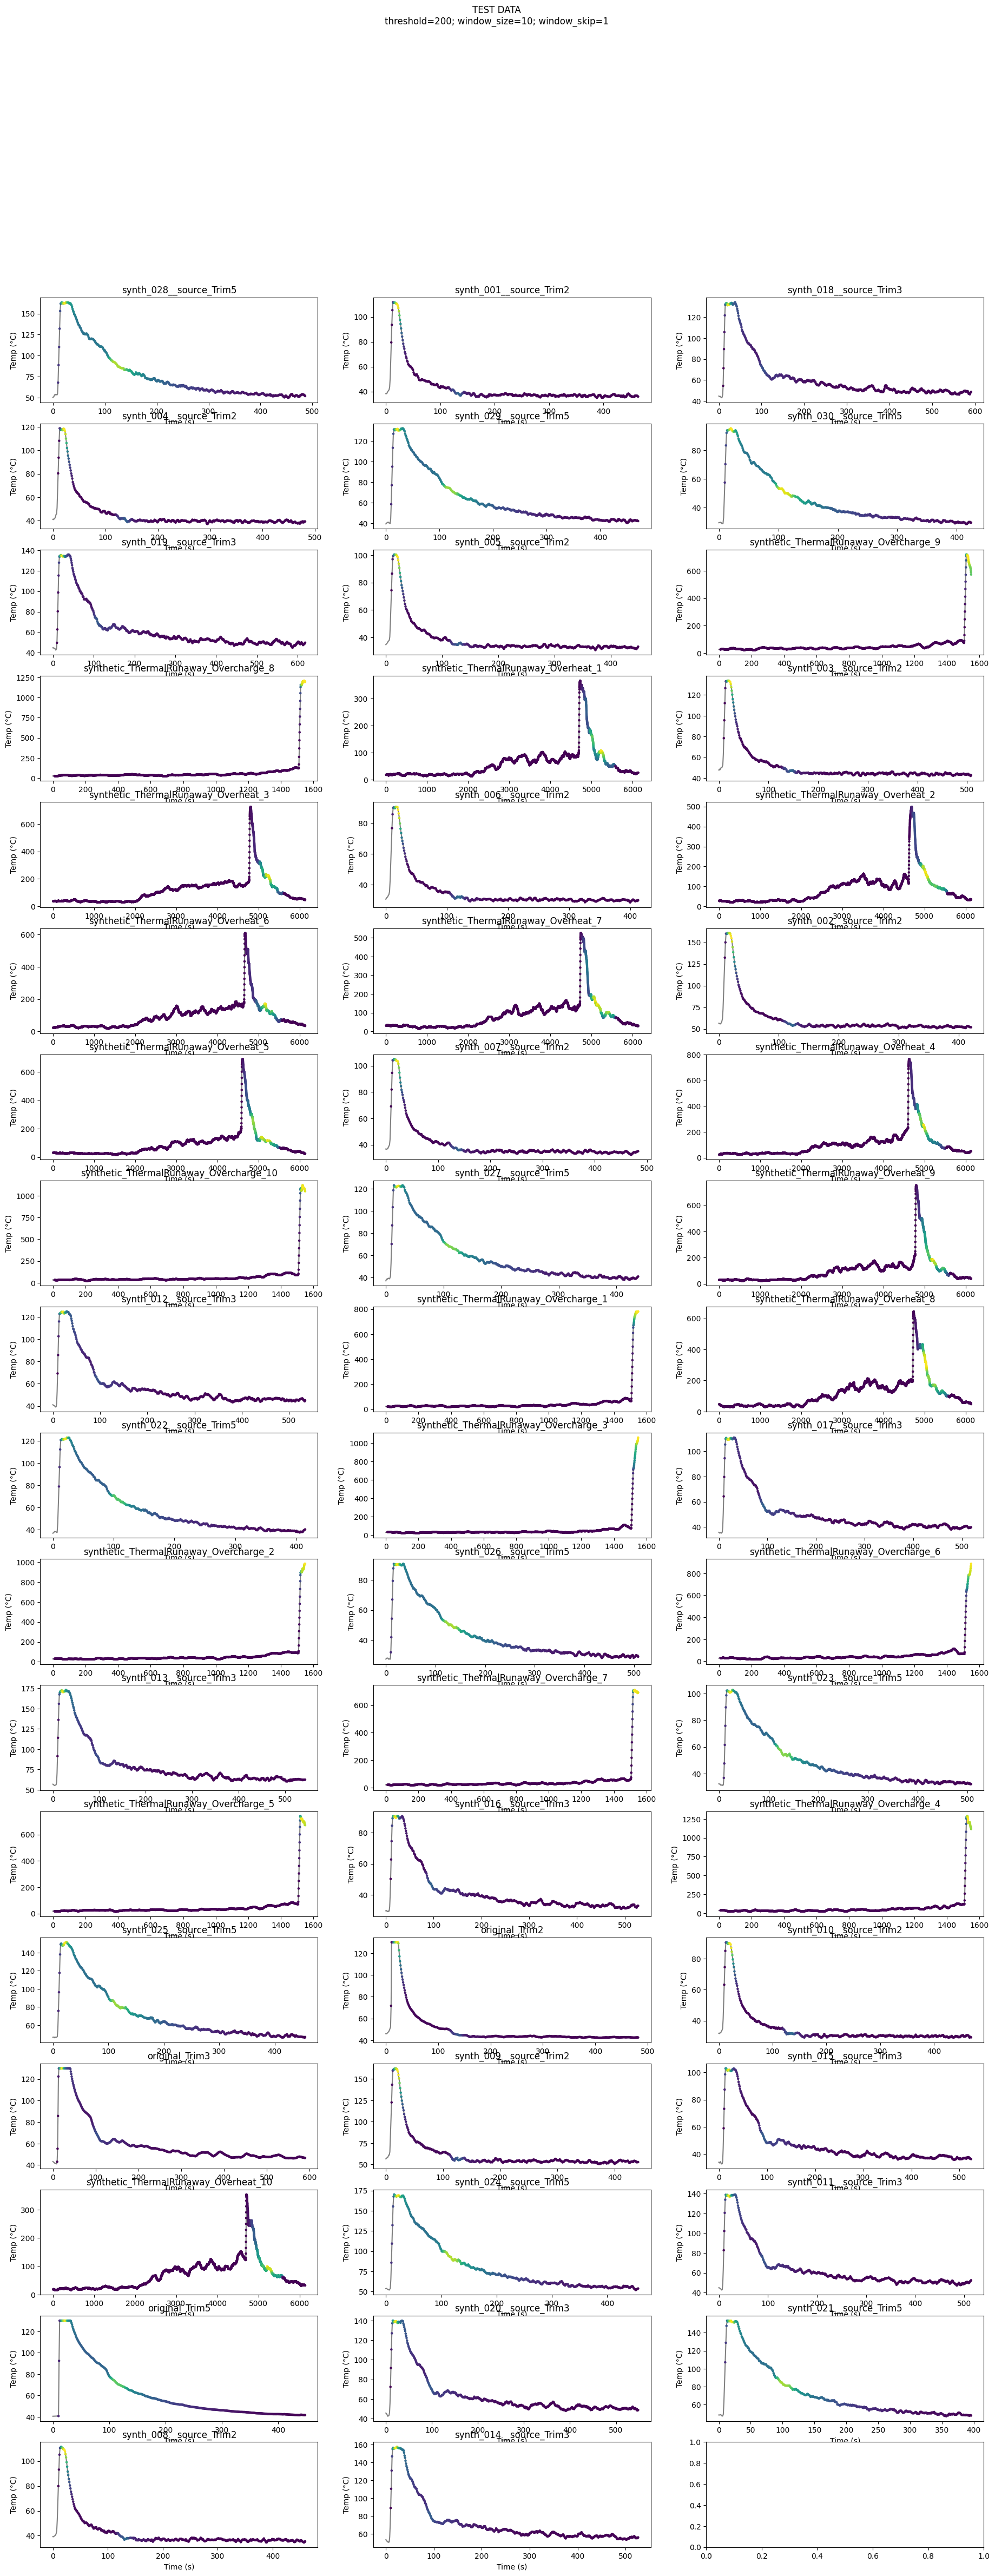

In [1]:
from src.validation import *

plot_multiple_errs_on_temp(
    "results/reconstruction_errs/unhealthyGASwTRIMS_w10.json",
    model_filename='results/trained_models/GASwTRIMS-3epoch_20window_1step_123params.pkl',
    threshold=200,
    sampling_rate=1
)

In [17]:
import json 
with open('results/reconstruction_errs/hanity_healthy_w20.json', 'r') as file:
    healthy_trims_reconstruction = json.load(file)
data = healthy_trims_reconstruction['data']

maximums = []
for filename in data:
    print(f"{filename}: {max(data[filename])}")
    maximums += [max(data[filename])]

data/preprocessed/Experiment_2_DiB_edit_Normal.pkl: 3.77876615524292
data/preprocessed/Experiment_3_DiB_edit_Normal.pkl: 0.6187554597854614
data/preprocessed/synthetic2_06.pkl: 0.3935810923576355
data/preprocessed/synthetic2_07.pkl: 1.5666813850402832
data/preprocessed/synthetic_09.pkl: 0.38917380571365356
data/preprocessed/synthetic_10.pkl: 0.6022988557815552
data/preprocessed/synthetic3_10.pkl: 0.9220326542854309
data/preprocessed/Synth_004_BeforeTest1.pkl: 0.5659834146499634
data/preprocessed/Synth_003_BeforeTest1.pkl: 0.5355656743049622
data/preprocessed/Synth_014_BeforeTest2.pkl: 0.3275647759437561
data/preprocessed/Synth_002_BeforeTest1.pkl: 0.5528072714805603
data/preprocessed/Synth_025_BeforeTest3.pkl: 0.6774870157241821
data/preprocessed/Synth_058_BeforeTest6.pkl: 0.004366565961390734
data/preprocessed/Synth_018_BeforeTest2.pkl: 0.32406026124954224
data/preprocessed/Synth_057_BeforeTest6.pkl: 0.0038027039263397455
data/preprocessed/Synth_017_BeforeTest2.pkl: 0.3318044543266296

In [19]:
import json 
with open('results/reconstruction_errs/unhealthyGASwTRIMS_w10.json', 'r') as file:
    unhealthy_reconstruction = json.load(file)
data = unhealthy_reconstruction['data']

maximums = []
for filename in data:
    print(f"{filename}: {max(data[filename])}")
    maximums += [max(data[filename])]

data/preprocessed/synth_028__source_Trim5.pkl: 323599.3125
data/preprocessed/synth_001__source_Trim2.pkl: 105719.3671875
data/preprocessed/synth_018__source_Trim3.pkl: 12055.49609375
data/preprocessed/synth_004__source_Trim2.pkl: 108287.203125
data/preprocessed/synth_029__source_Trim5.pkl: 160772.046875
data/preprocessed/synth_030__source_Trim5.pkl: 288211.46875
data/preprocessed/synth_019__source_Trim3.pkl: 24437.423828125
data/preprocessed/synth_005__source_Trim2.pkl: 87831.75
data/preprocessed/synthetic_ThermalRunaway_Overcharge_9.pkl: 151106.390625
data/preprocessed/synthetic_ThermalRunaway_Overcharge_8.pkl: 446262.40625
data/preprocessed/synthetic_ThermalRunaway_Overheat_1.pkl: 29182202.0
data/preprocessed/synth_003__source_Trim2.pkl: 67354.2421875
data/preprocessed/synthetic_ThermalRunaway_Overheat_3.pkl: 104544112.0
data/preprocessed/synth_006__source_Trim2.pkl: 49453.8046875
data/preprocessed/synthetic_ThermalRunaway_Overheat_2.pkl: 41782100.0
data/preprocessed/synthetic_Therma

In [20]:
sorted(maximums)

[9059.4111328125,
 12055.49609375,
 12435.0244140625,
 13124.0087890625,
 14494.58203125,
 15750.5556640625,
 15774.671875,
 17649.220703125,
 19451.0625,
 19692.7578125,
 24437.423828125,
 49453.8046875,
 50190.2265625,
 53725.20703125,
 67354.2421875,
 78335.1015625,
 87831.75,
 88636.0078125,
 90306.875,
 105719.3671875,
 108287.203125,
 109521.3203125,
 116573.0546875,
 147568.421875,
 151106.390625,
 155688.25,
 156268.65625,
 160772.046875,
 180039.578125,
 201231.15625,
 223313.90625,
 231742.0,
 259798.3125,
 281524.0,
 288211.46875,
 288773.1875,
 299118.09375,
 313522.84375,
 323599.3125,
 364227.875,
 375351.46875,
 446262.40625,
 509549.03125,
 24410700.0,
 29182202.0,
 37910676.0,
 41782100.0,
 42071656.0,
 60089548.0,
 63918276.0,
 87674792.0,
 90998944.0,
 104544112.0]

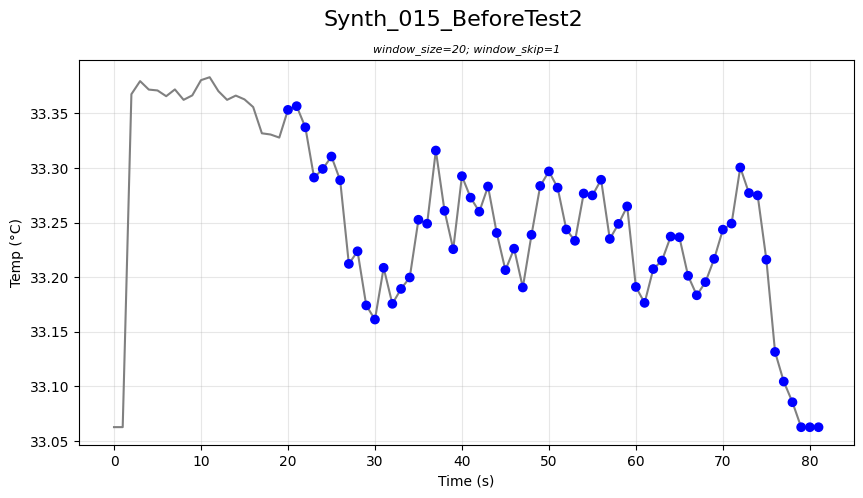

In [23]:
from src.validation import *
filename = "data/preprocessed/Synth_015_BeforeTest2.pkl"

Synth_015_BeforeTest2_evals = evaluate_and_plot(
    filename,
    transformer_model,
    window_size=window_size,
    window_skip=window_skip,
    threshold=200,
    index_tuple=index_tuple
)

In [25]:
healthy_test_errors = get_reconstruction_errors(transformer_model, healthy_test_loader, 'mps')

In [26]:
max(healthy_test_errors)

110.91954803466797

In [27]:
unhealthy_test_errors = get_reconstruction_errors(transformer_model, unhealthy_test_loader, 'mps')

In [43]:
import statistics

print(f"Gas data reconstruction errors on test sets:")
print(f"\t model = {model_filename}")
print(f"-------------------------------")
print(f"\t | HEALTHY | UNHEALTHY")
print(f"-------------------------------")
print(f"MAX:\t | {max(healthy_test_errors):.2f}  | {max(unhealthy_test_errors):.2f}")

print(f"MEDIAN:\t | {statistics.median(healthy_test_errors):.2f}   | {statistics.median(unhealthy_test_errors):.2f}")

print(f"MIN:\t | {min(healthy_test_errors):.2f}   | {min(unhealthy_test_errors):.2f}")

print(f"MEAN:\t | {sum(healthy_test_errors)/len(healthy_test_errors):.2f}   | {sum(unhealthy_test_errors)/len(unhealthy_test_errors):.2f}")


Gas data reconstruction errors on test sets:
	 model = results/trained_models/GAS-3epoch_20window_1step_123params.pkl
-------------------------------
	 | HEALTHY | UNHEALTHY
-------------------------------
MAX:	 | 110.92  | 346333.47
MEDIAN:	 | 46.87   | 1889.44
MIN:	 | 26.64   | 131.32
MEAN:	 | 50.46   | 55421.62


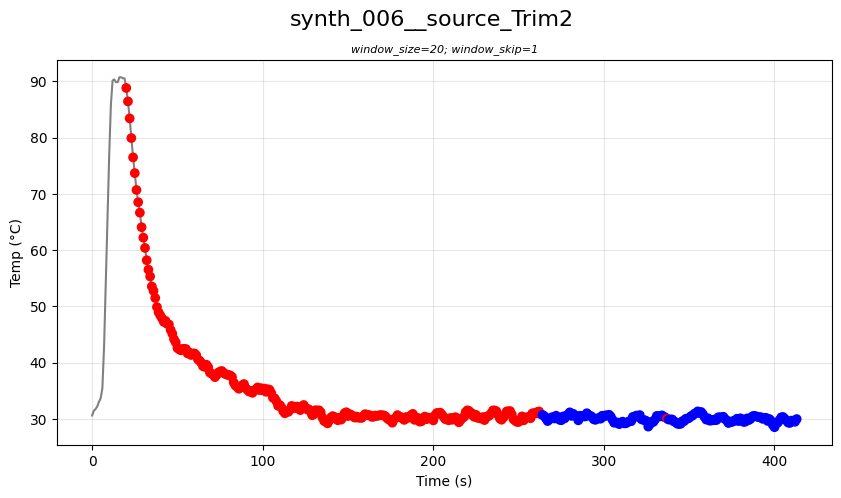

In [24]:
from src.validation import *
filename = "data/preprocessed/synth_006__source_Trim2.pkl"

synth_006__source_Trim2_evals = evaluate_and_plot(
    filename,
    transformer_model,
    window_size=window_size,
    window_skip=window_skip,
    threshold=200,
    index_tuple=index_tuple
)

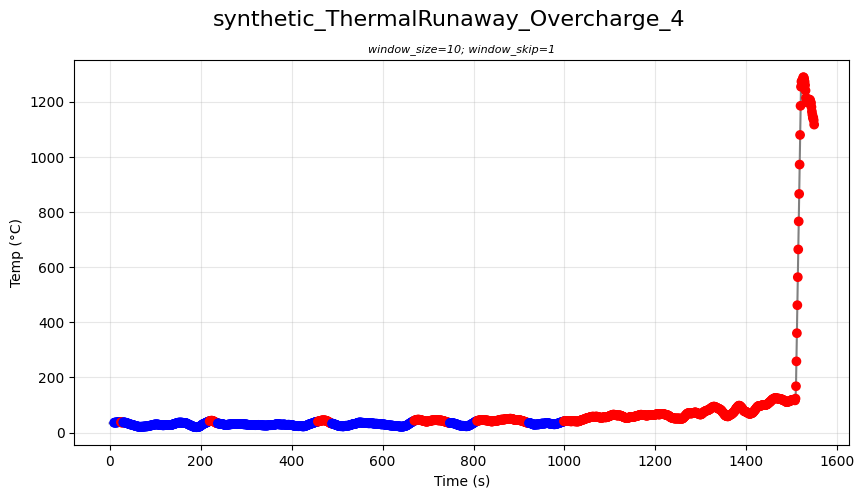

In [9]:
from src.validation import *
filename = "data/preprocessed/synthetic_ThermalRunaway_Overcharge_4.pkl"

overcharge_evals = evaluate_and_plot(
    filename,
    transformer_model,
    window_size=10,
    window_skip=1,
    threshold=200,
    index_tuple=index_tuple
)

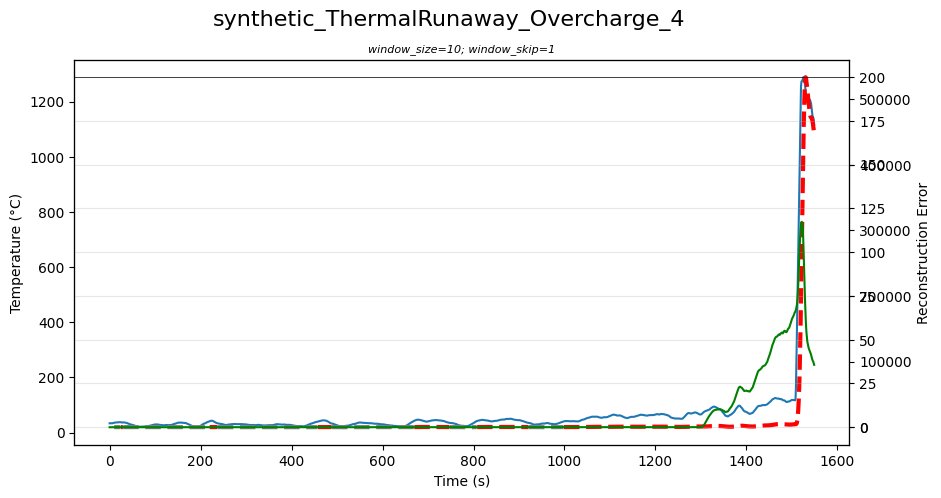

In [12]:
import numpy as np
def plot_errs_on_tempgas(filename, errors, window_size=20, window_skip=1, sampling_rate=1, figsize=(10,5), xlim=None, templim=None, errlim=None, **kwargs):
    """
    Plots the temperature data in the given file with dots indicating whether the data was classified as healthy
    or unhealthy at various timesteps.
    """
    # Get temperature data
    bd = BatteryData.load(filename)
    temps = bd.timeseries_data[0].to_dict()['temperature_in_C']
    temps = np.array(list(temps))
    y = temps[~np.isnan(temps)]
    x = np.arange(len(y)) / sampling_rate

    # Plot the line
    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.plot(x, y, label='Temp')
    ax1.set_ylabel("Temperature (°C)")
    ax1.set_xlabel("Time (s)")

    # Overlay colored dots
    i = np.arange(len(errors))
    idx = i * window_skip + window_size
    idx = idx[:len(x)-window_size]

    
    threshold = 200
    # plt.fill_between(x, 200, 2000, alpha=0.3, color='pink')

    ax2 = ax1.twinx()
    # ax2.plot(x[idx], errors, label="Err", color='red', linestyle='--')
    ax2.set_ylabel("Reconstruction Error")
    errors = np.array(errors)

    below = np.ma.masked_where(errors > threshold, errors)
    above = np.ma.masked_where(errors <= threshold, errors)

    ax2.plot(x[idx], below, color='grey', linestyle='--', linewidth=3)
    ax2.plot(x[idx], above, color='red', linestyle='--', linewidth=3)

    # Plot gas
    h2 = bd.timeseries_data[0].to_dict()['h2_ppmo']
    h2 = np.array(list(h2))
    ax3 = ax1.twinx()
    ax3.plot(x, h2, label='H2', color='green')



    if xlim is not None: plt.xlim(xlim)
    if templim is not None: ax1.set_ylim(0, templim)
    if errlim is not None: ax2.set_ylim(0, errlim)

    plt.axhline(
        y=200,
        color='black',
        linewidth=0.5
    )

    # Make it nice
    plt.suptitle(f"{filename.split('/')[-1].split('.')[0]}", fontsize=16)
    plt.title(f"window_size={window_size}; window_skip={window_skip}", fontdict=SUBTITLE_FONT)
    plt.grid(alpha=0.3)


plot_errs_on_tempgas(
    filename, 
    crps_reconstruction['data'][filename],
    10
)